# DAGrad Engine Showcase

This notebook demonstrates core usage patterns of the DAGrad engine using small, trainable examples built with PyTorch.

What you will see:
- How to define custom `Block` classes and register trainable parameters.
- How to compose blocks into a `Workflow` and run forward passes.
- How gradients flow through workflow blocks during optimization.
- How to build and train a multi-input graph workflow with named edges/outputs.

## Imports

Load the base DAGrad abstractions used throughout the notebook:
- `Block`: defines reusable computation units.
- `Workflow`: orchestrates block execution in sequential or graph mode.

In [1]:
from dagrad.engine.block import Block
from dagrad.engine.workflow import Workflow

## Define Example Blocks and Workflow

This section builds a simple trainable polynomial workflow from three blocks:
- `ExampleBlock`: identity pass-through (`x`).
- `ExampleBlock2`: quadratic term (`x + a * x^2`) with learnable parameter `a`.
- `ExampleBlock3`: bias term (`x + c`) with learnable parameter `c`.

When chained in sequence, the workflow can approximate targets of the form:
$y \approx x + a x^2 + c$

The goal is to verify that:
- parameters are registered correctly,
- data flows through each block in order, and
- gradients update `a` and `c` during training.

In [2]:
class ExampleBlock(Block):
    def __init__(self):
        super().__init__()
    
    def execute(self, x):
        return x

class ExampleBlock2(Block):
    def __init__(self):
        super().__init__()
        self.add_param(1.0, symbol="a", trainable=True)
    
    def execute(self, x):
        return x + self.a * x**2
    
class ExampleBlock3(Block):
    def __init__(self):
        super().__init__()
        self.add_param(1.0, symbol="c", trainable=True)

    def execute(self, x):
        return x + self.c
    
class ExampleWorkflow(Workflow):
    def __init__(self):
        super().__init__()
        self.add_block(ExampleBlock())
        self.add_block(ExampleBlock2())
        self.add_block(ExampleBlock3())

## Train the Workflow (Sequential and Graph Examples)

In the next code cells, you will train two workflows against synthetic targets:
1. **Sequential workflow** (`ExampleWorkflow`) using insertion-order execution.
2. **Graph workflow** (`MultiInputWorkflow`) using explicit named connections and outputs.

Training setup:
- Input domain: `x` sampled from `[-5, 5]`.
- Target: $y_{gt} = 2x^2 + x$.
- Loss: `L1Loss`.
- Optimizer: `Adam`.

Every 100 epochs, plots compare prediction vs. ground truth, and titles report current loss plus learned parameter values.

# ExampleWorkflow ASCII DAG
```text
workflow input: x
   |
   |      
   v       
[ExampleBlock]
   |out
   |        
   v   
[ExampleBlock2]
   |out
   |        
   v      
[ExampleBlock3]
   |out
   |        
   v
workflow output: out 
```

ExampleWorkflow:
┌───────────────┐
│ ExampleBlock: │
│               │
└───────────────┘
   │
   ▼
┌─────────────────────────────┐
│ ExampleBlock2:              │
│     a: 1.0 (trainable=True) │
└─────────────────────────────┘
   │
   ▼
┌─────────────────────────────┐
│ ExampleBlock3:              │
│     c: 1.0 (trainable=True) │
└─────────────────────────────┘


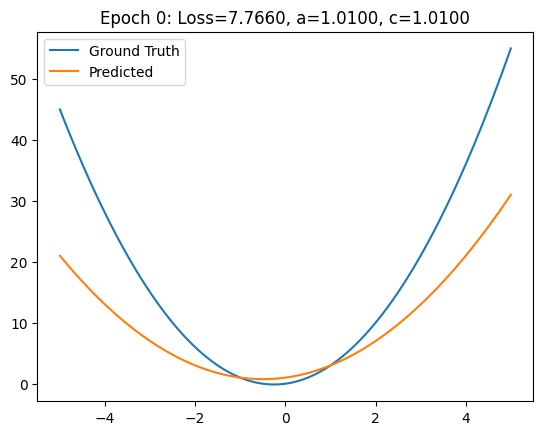

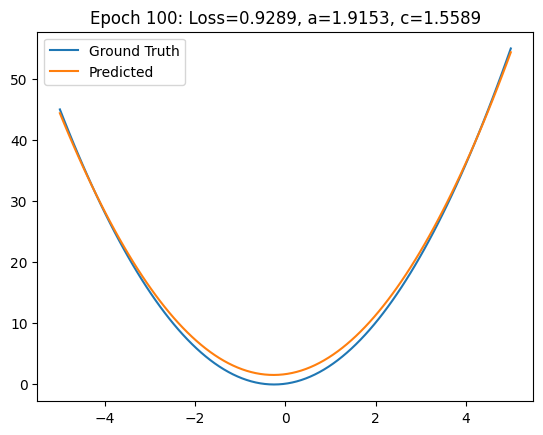

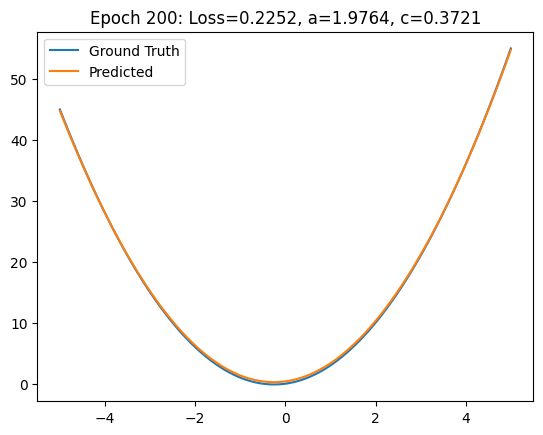

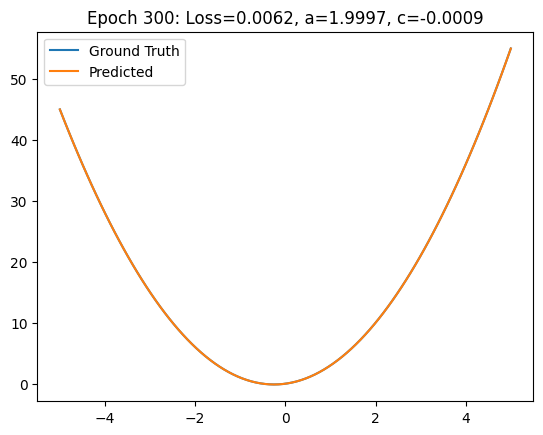

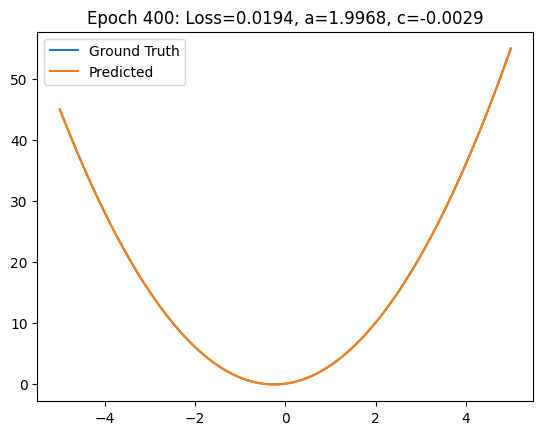

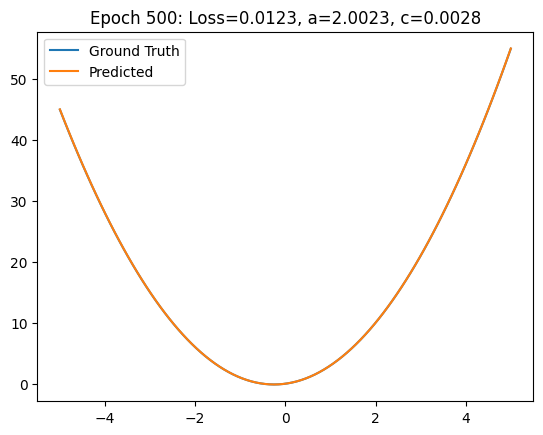

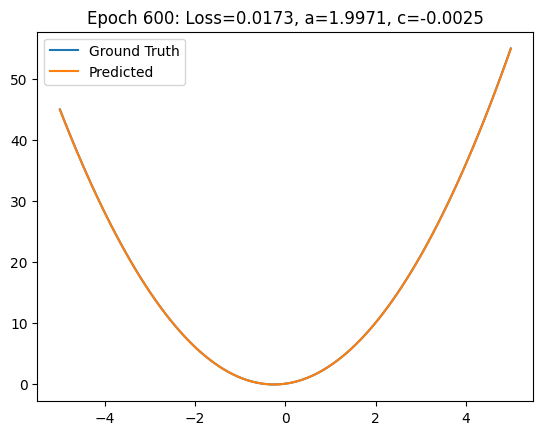

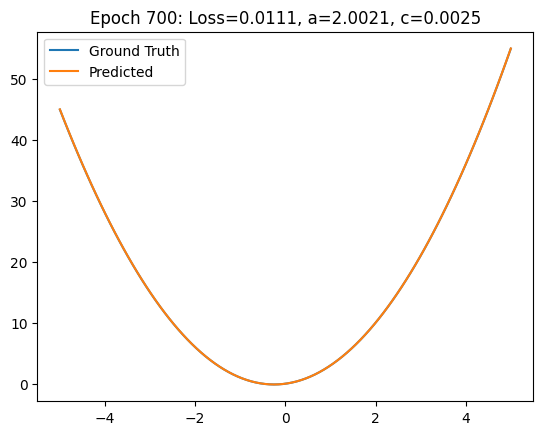

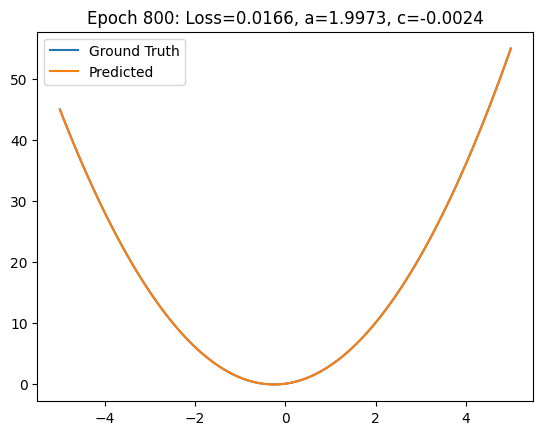

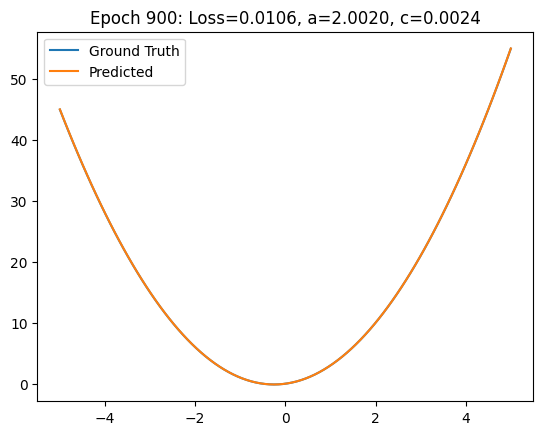

In [3]:
# Generate some test data
import torch
import matplotlib.pyplot as plt

workflow = ExampleWorkflow()
print(workflow)
workflow = workflow.to("cuda" if torch.cuda.is_available() else "cpu")

x = torch.linspace(-5, 5, steps=100)
x = x.to("cuda" if torch.cuda.is_available() else "cpu")
y_gt = 2 * x**2 + x + 0.0

loss_fn = torch.nn.L1Loss()
adam = torch.optim.Adam(workflow.parameters(), lr=0.01)

for epoch in range(1000):
    y_pred = workflow.run(x)
    loss = loss_fn(y_pred, y_gt)
    
    adam.zero_grad()
    loss.backward()
    adam.step()
    
    if epoch % 100 == 0:
        plt.plot(x.cpu(), y_gt.cpu(), label="Ground Truth")
        plt.plot(x.cpu(), y_pred.detach().cpu(), label="Predicted")
        plt.title(f"Epoch {epoch}: Loss={loss.item():.4f}, a={workflow.blocks[1].a.item():.4f}, c={workflow.blocks[2].c.item():.4f}")
        plt.legend()
        plt.show()

## How this workflow is different (Graph mode)

Unlike the previous example (sequential mode), this workflow uses **explicit graph wiring** with named nodes, named input ports, and named output ports.

### Key differences from sequential mode
- **Named blocks** are added with keys: `"a*x^2"`, `"c"`, `"x"`, and `"polynom"`.
- Execution is driven by dependency edges (topological order), not just insertion order.
- Each block returns a dictionary (for example `{\"out\": ...}`), so downstream blocks can consume specific output ports.

### Exact connections used in this workflow
- `connect_input("x", "a*x^2", dst_input="x")`
  - Routes workflow input `x` into the `a*x^2` block as its `x` argument.
- `connect_input("x", "x", dst_input="x")`
  - Routes the same workflow input `x` into the pass-through `x` block.
- `connect("a*x^2", "polynom", src_output="out", dst_input="x_sqrt")`
  - Sends the quadratic term into `Polynom.execute(..., x_sqrt=...)`.
- `connect("x", "polynom", src_output="out", dst_input="x")`
  - Sends the linear term into `Polynom.execute(..., x=...)`.
- `connect("c", "polynom", src_output="out", dst_input="offset")`
  - Sends the bias term into `Polynom.execute(..., offset=...)`.

### Exposed workflow outputs
`set_outputs(...)` defines multiple named outputs:
- `prediction -> ("polynom", "out")`
- `x^2 -> ("a*x^2", "out")`
- `x -> ("x", "out")`
- `offset -> ("c", "out")`

This lets you train on `outputs["prediction"]` while also inspecting intermediate terms for debugging and interpretability.

### ASCII DAG
```text
workflow input: x
   |\
   | \
   |  \
   |   \
   |    \
   |     \
   |      \
   v       v
[a*x^2]   [x]      [c]
   |out     |out    |out
   |        |       |
   |        |       |
   |        v       v
   +----> [   polynom   ]
          inputs: x_sqrt, x, offset
                  |out
                  v
            prediction
```

In [ ]:
class FirstTerm(Block):
    def __init__(self):
        super().__init__()

    def execute(self, x):
        return {"out": x}
    

class SecondTerm(Block):
    def __init__(self, scale):
        super().__init__()
        self.add_param(scale, symbol="scale", trainable=True)

    def execute(self, x):
        return {"out": self.scale * x**2}


class ThirdTerm(Block):
    def __init__(self, offset):
        super().__init__()
        self.add_param(offset, symbol="offset", trainable=True)

    def execute(self):
        return {"out": self.offset}


class Polynom(Block):
    def __init__(self):
        super().__init__()

    def execute(self, x_sqrt, x, offset):
        return {"out": x_sqrt + x + offset}


class MultiInputWorkflow(Workflow):
    def __init__(self):
        super().__init__()

        self.add_block(SecondTerm(scale=1.0), key="a*x^2")
        self.add_block(ThirdTerm(offset=1.0), key="c")
        self.add_block(FirstTerm(), key="x")
        self.add_block(Polynom(), key="polynom")

        self.connect_input("x", "a*x^2", dst_input="x")
        self.connect_input("x", "x", dst_input="x")

        self.connect("a*x^2", "polynom", src_output="out", dst_input="x_sqrt")
        self.connect("x", "polynom", src_output="out", dst_input="x")
        self.connect("c", "polynom", src_output="out", dst_input="offset")

        self.set_outputs(
            {
                "prediction": ("polynom", "out"),
                "x^2": ("a*x^2", "out"),
                "x": ("x", "out"),
                "offset": ("c", "out")
            }
        )

MultiInputWorkflow: [graph mode]

  Workflow Input:
      [Workflow Input] OutputPort(x) ──▶ [SecondTerm] InputPort(x)

       <no incoming connections> ──▶ [ThirdTerm] InputPort()

      [Workflow Input] OutputPort(x) ──▶ [FirstTerm] InputPort(x)

  Past workflow input nodes:
      [SecondTerm] OutputPort(out) ──▶ [Polynom] InputPort(x_sqrt)
      [FirstTerm] OutputPort(out) ──▶ [Polynom] InputPort(x)
      [ThirdTerm] OutputPort(out) ──▶ [Polynom] InputPort(offset)

  Workflow outputs:
     [Polynom] OutputPort(out) ──▶ prediction
     [SecondTerm] OutputPort(out) ──▶ x^2
     [FirstTerm] OutputPort(out) ──▶ x
     [ThirdTerm] OutputPort(out) ──▶ offset


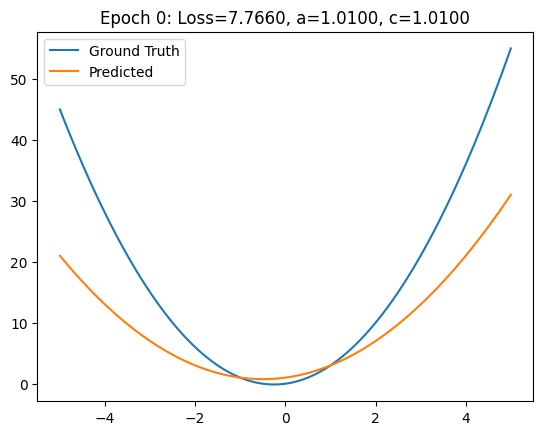

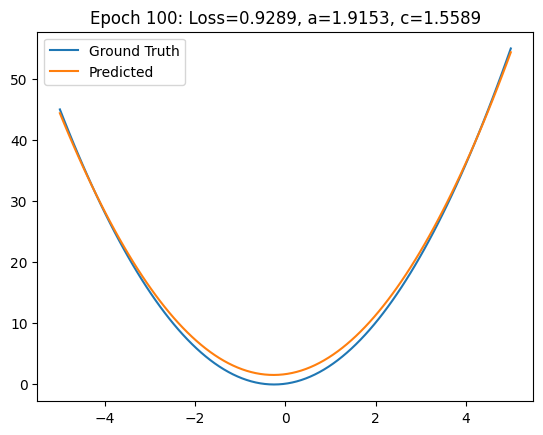

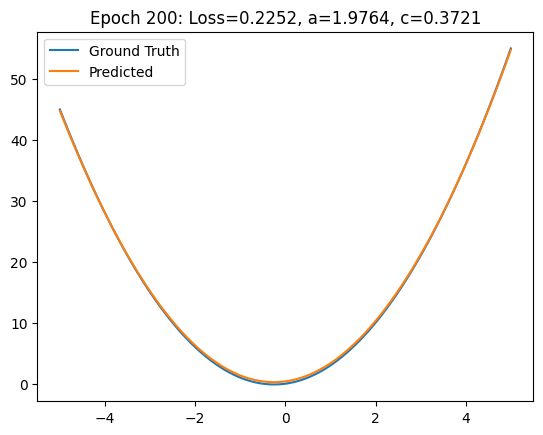

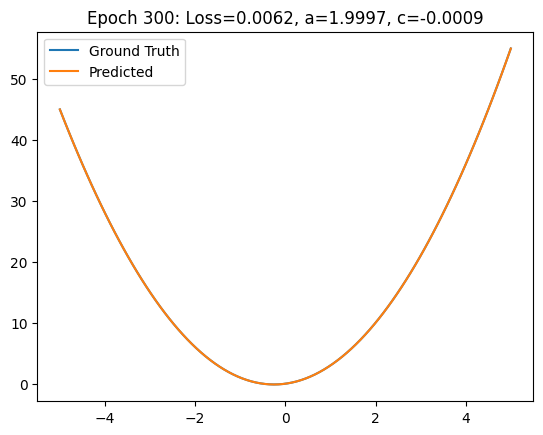

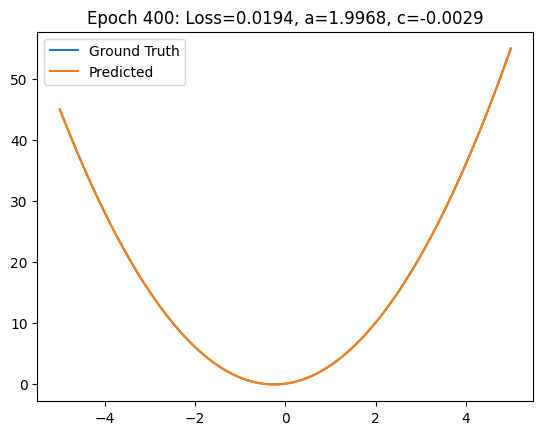

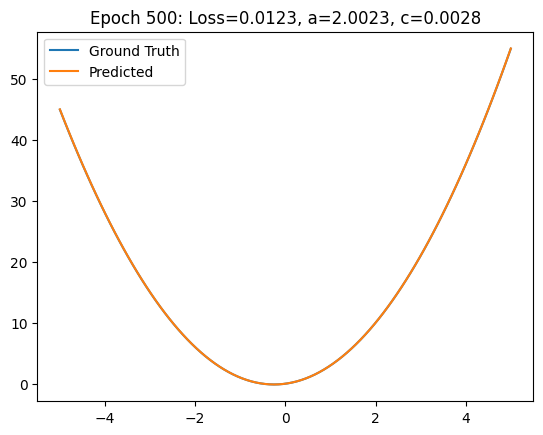

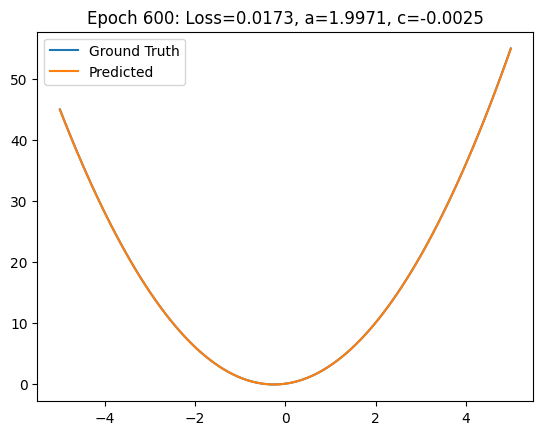

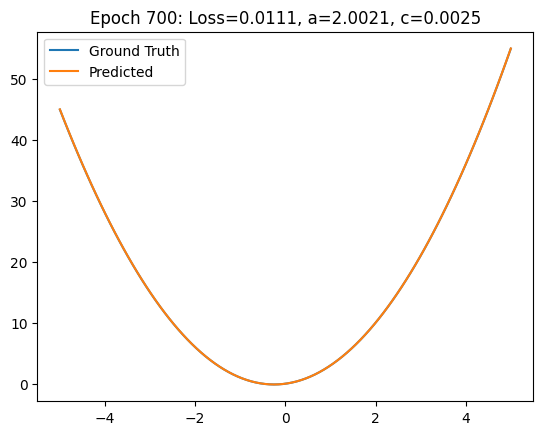

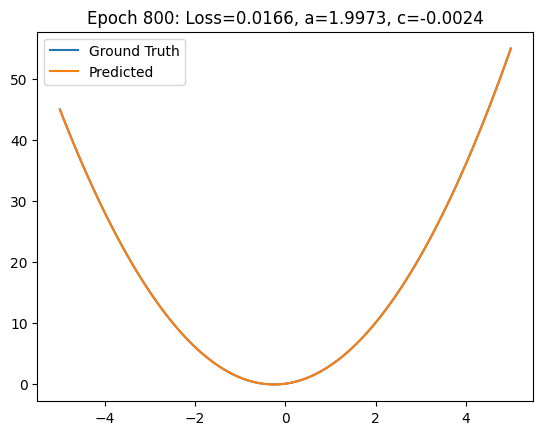

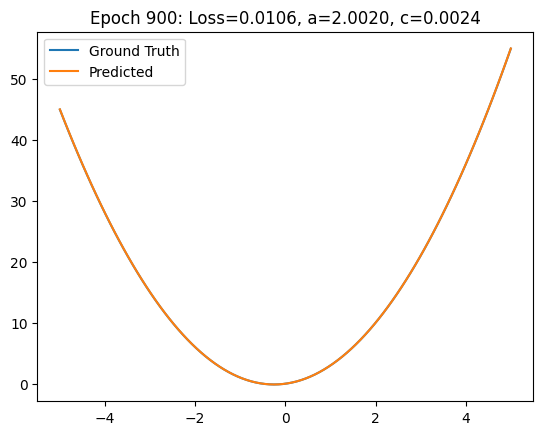

In [5]:
multi_workflow = MultiInputWorkflow()
print(multi_workflow)
multi_workflow = multi_workflow.to("cuda" if torch.cuda.is_available() else "cpu")

x = torch.linspace(-5, 5, steps=100)
x = x.to("cuda" if torch.cuda.is_available() else "cpu")
y_gt = 2 * x**2 + x + 0.0

loss_fn = torch.nn.L1Loss()
adam = torch.optim.Adam(multi_workflow.parameters(), lr=0.01)

for epoch in range(1000):
    outputs = multi_workflow.run({"x": x})
    y_pred = outputs["prediction"]
    loss = loss_fn(y_pred, y_gt)
    
    adam.zero_grad()
    loss.backward()
    adam.step()
    
    if epoch % 100 == 0:
        plt.plot(x.cpu(), y_gt.cpu(), label="Ground Truth")
        plt.plot(x.cpu(), y_pred.detach().cpu(), label="Predicted")
        plt.title(
            f"Epoch {epoch}: Loss={loss.item():.4f}, "
            f"a={multi_workflow.blocks[0].scale.item():.4f}, "
            f"c={multi_workflow.blocks[1].offset.item():.4f}"
        )
        plt.legend()
        plt.show()